In [114]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [260]:
# 1. Data on Terms of Trade: 81000-0033_env.csv | Adjusted data, 2020 = 100
df_tot = pd.read_csv("./data/81000-0033_en.csv")

# Transpose the dataset to bring year on columns
df_tot = df_tot.T

# Remove the default index
df_tot.reset_index(inplace=True)

# Delete the first row as we don't need it
df_tot = df_tot.iloc[2:]

# Rename the columns
df_tot = df_tot.rename(columns={
    'index': 'year',
    0: 'terms of trade',
    1: 'exports',
    2: 'imports',
})

# Drop false rows
df_tot = df_tot[df_tot['terms of trade'] != 'e']
df_tot = df_tot[df_tot['terms of trade'] != 'p']

# Set new index
df_tot.set_index("year", inplace=True)
df_tot.index = df_tot.index.astype(int)

# Print the head of table
df_tot.head()

,terms of trade,exports,imports
year,,,
1991,91.68,86.74,94.61
1992,94.43,87.63,92.8
1993,96.06,87.73,91.33
1994,96.78,88.27,91.21
1995,97.85,89.31,91.27


In [263]:
print(df_tot['terms of trade'].astype(float).max())
print(df_tot['terms of trade'].astype(float).min())
print(df_tot['terms of trade'].astype(float).mean())
print(df_tot['terms of trade'].astype(float).std())

100.0
91.68
96.42571428571429
2.1381249147934507


In [116]:
# 2. Data on Imports by industries (2021=100)
df_imp = pd.read_csv("data/61411-0007_en.csv")

# Transpose the dataset to delete the false columns
df_imp = df_imp.T

# Remove the first row of variable codes
df_imp = df_imp[1:]

# Change the column names to the names of first row columns
df_imp.columns = df_imp.loc['Unnamed: 1']
df_imp.columns = df_imp.columns.str.lower()

# Reset index
df_imp.reset_index(inplace=True)
df_imp = df_imp.rename(columns={'index': 'year'})
df_imp.set_index('year', inplace=True)

# Remove the new first row
df_imp = df_imp[1:]

# Drop unrequired rows
df_imp = df_imp[df_imp['food'] != 'e']
df_tot = df_tot[df_tot['terms of trade'] != 'p']

# Sort by year
df_imp = df_imp.sort_index()

df_imp.index = df_imp.index.astype(int)
df_imp = df_imp[df_imp.index > 1990]

df_imp.head()

Unnamed: 1,live animals,nutritional goods of animal origin,food,food of animal origin,food of vegetable origin,nutritional goods of vegetable origin,"tea, coffee, tobacco, alcoholic beverages",raw materials,raw materials and semi-finished goods,industrial products,semi-finished goods,intermediate products,finished goods,end products,total
year,,,,,,,,,,,,,,,
1991,-,72.9,69.7,71.5,69.5,68.3,63.9,-,32.2,80.1,38.9,64.9,100.3,109,78.9
1992,-,72.8,67.5,71.3,66.8,65.4,59.8,-,28.9,78.3,34.9,61.7,99.7,109.6,77
1993,-,68.6,65.3,67.3,64.9,64,60.4,-,27.6,77.2,33.5,59.2,99,109.8,75.8
1994,-,67.6,68.2,66.3,67,68.3,73.7,-,27.7,77.5,34.1,60.7,99.6,109.8,76.4
1995,-,67.6,66.5,66.2,64.9,65.9,70.5,-,28.3,77.9,35.2,64.7,99.9,108.3,76.6


In [117]:
# 3. Data on exports: 2021=100
df_exp = pd.read_csv("data/61421-0007_en.csv")

# Transpose the dataset to delete the false columns
df_exp = df_exp.T

# Remove the first row of variable codes
df_exp = df_exp[1:]

# Change the column names to the names of first row columns
df_exp.columns = df_exp.loc['Unnamed: 1']
df_exp.columns = df_exp.columns.str.lower()

# Reset index
df_exp.reset_index(inplace=True)
df_exp = df_exp.rename(columns={'index': 'year'})
df_exp.set_index('year', inplace=True)

# Remove the new first row
df_exp = df_exp[1:]

# Drop unrequired rows
df_exp = df_exp[df_exp['food'] != 'e']
df_tot = df_tot[df_tot['terms of trade'] != 'p']

# Sort by year
df_exp = df_exp.sort_index()

df_exp.index = df_exp.index.astype(int)
df_exp = df_exp[df_exp.index > 1990]

df_exp.head()

Unnamed: 1,food and industrial products,live animals,nutritional goods of animal origin,food,food of animal origin,food of vegetable origin,nutritional goods of vegetable origin,"tea, coffee, tobacco, alcoholic beverages",raw materials,raw materials and semi-finished goods,industrial products,semi-finished goods,intermediate products,finished goods,end products
year,,,,,,,,,,,,,,,
1991,-,-,71.2,69.6,70.4,70.6,68.5,62.5,-,41.8,77.8,41.7,67.5,81.2,83.7
1992,-,-,73.7,70.3,72.2,69.9,68.1,62.8,-,40.2,78.4,40,65.2,82,85.3
1993,-,-,70.9,68.6,69.4,69.2,67.1,60.9,-,39.1,78.5,38.9,63.3,82.4,86.3
1994,-,-,70.9,70.2,69.3,71.5,69.7,64.5,-,40.6,79.1,40,64.3,82.7,86.7
1995,-,-,70.3,69.6,69.1,70.6,69.2,65.3,-,42.1,80.3,41.2,68.3,83.9,87


([<matplotlib.axis.XTick at 0x3034b8620>,
 [Text(1991, 0, '1991'),
  Text(1993, 0, '1993'),
  Text(1995, 0, '1995'),
  Text(1997, 0, '1997'),
  Text(1999, 0, '1999'),
  Text(2001, 0, '2001'),
  Text(2003, 0, '2003'),
  Text(2005, 0, '2005'),
  Text(2007, 0, '2007'),
  Text(2009, 0, '2009'),
  Text(2011, 0, '2011'),
  Text(2013, 0, '2013'),
  Text(2015, 0, '2015'),
  Text(2017, 0, '2017'),
  Text(2019, 0, '2019'),
  Text(2021, 0, '2021'),
  Text(2023, 0, '2023'),
  Text(2025, 0, '2025')])

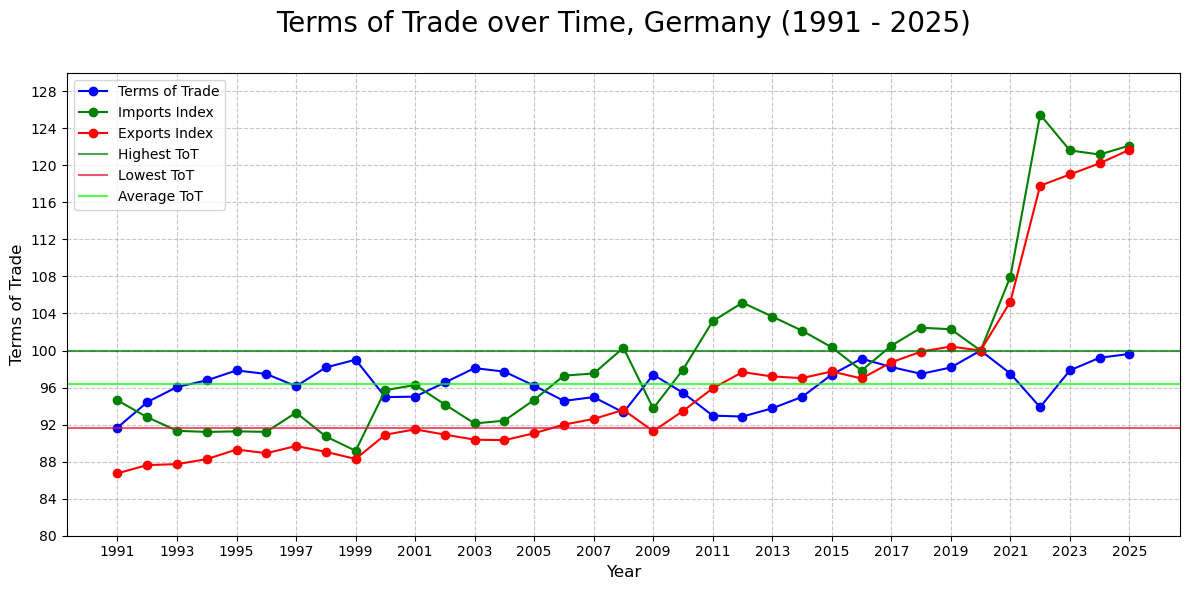

In [176]:
x = df_tot['terms of trade']
e = df_tot['exports']
i = df_tot['imports']
plt.figure(figsize=(12, 6))
plt.plot(x.index, x.values.astype(float), color='blue', marker='o', linestyle='-', label="Terms of Trade")
plt.plot(x.index, i.values.astype(float), color='green', marker='o', linestyle='-', label="Imports Index")
plt.plot(x.index, e.values.astype(float), color='red', marker='o', linestyle='-', label="Exports Index")
plt.ylim(80, 130)
plt.yticks(range(80, 131, 4))
plt.axhline(y=100, alpha=0.3, linestyle='--')
plt.axhline(y=x.values.astype(float).max(), alpha=0.7, color='green', linestyle='-', label='Highest ToT')
plt.axhline(y=x.values.astype(float).min(), alpha=0.7, color='crimson', linestyle='-', label='Lowest ToT')
plt.axhline(y=x.values.astype(float).mean(), alpha=0.7, color='lime', linestyle='-', label='Average ToT')
plt.title("Terms of Trade over Time, Germany (1991 - 2025)\n", fontsize=20)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Terms of Trade", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend()
plt.xticks(range(1991, 2026, 2))

In [ ]:
merged_exp = pd.merge(df_exp, df_tot, on="year")
merged_exp = merged_exp.drop(columns=['food and industrial products', 'raw materials', 'live animals', 'imports'])



merged_exp.corrwith(merged_exp['exports']).sort_values()

terms of trade                               0.273856
semi-finished goods                          0.913236
raw materials and semi-finished goods        0.917274
intermediate products                        0.958647
tea, coffee, tobacco, alcoholic beverages    0.973115
food of animal origin                        0.973901
nutritional goods of animal origin           0.976071
food of vegetable origin                     0.980539
nutritional goods of vegetable origin        0.981717
food                                         0.982175
end products                                 0.984198
industrial products                          0.985726
finished goods                               0.990823
exports                                      1.000000
dtype: float64

We identify that finished goods, industrial products, and end products have the highest correlation with exports in Germany. So, we study their variation with terms of trade.

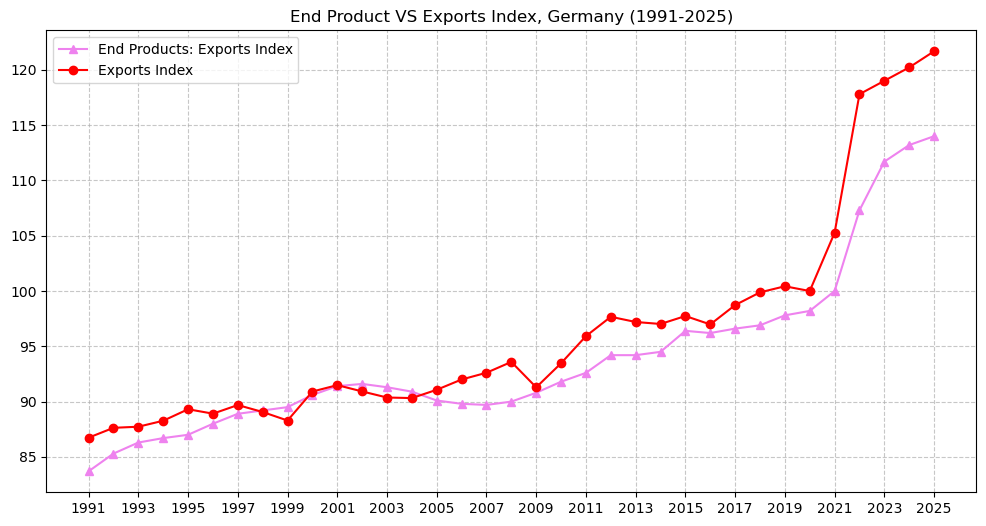

In [268]:
plt.figure(figsize=(12, 6))

# plt.plot(merged_exp['finished goods'].astype(float), label="Finished Goods: Exports Index")
# plt.plot(merged_exp['industrial products'].astype(float), label="Industrial Products: Exports Index")
plt.plot(merged_exp['end products'].astype(float), color='violet', marker="^", label="End Products: Exports Index")

# plt.plot(x.index, x.values.astype(float), color='blue', marker='o', linestyle='-', label="Terms of Trade")
plt.plot(x.index, e.values.astype(float), color='red', marker='o', linestyle='-', label="Exports Index")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.title("End Product VS Exports Index, Germany (1991-2025)")
plt.xticks(range(1991, 2026, 2))

plt.show()

In [162]:
merged_imp = pd.merge(df_imp, df_tot, on="year")
merged_imp = merged_imp.drop(columns=['raw materials', 'live animals', 'total',])
merged_imp.corrwith(merged_imp['imports']).sort_values()

end products                                 0.002425
terms of trade                               0.048326
finished goods                               0.645593
raw materials and semi-finished goods        0.905955
tea, coffee, tobacco, alcoholic beverages    0.909624
semi-finished goods                          0.926769
nutritional goods of vegetable origin        0.951384
food of vegetable origin                     0.953970
food                                         0.957110
nutritional goods of animal origin           0.964734
industrial products                          0.965876
intermediate products                        0.967170
food of animal origin                        0.967890
exports                                      0.973644
imports                                      1.000000
dtype: float64

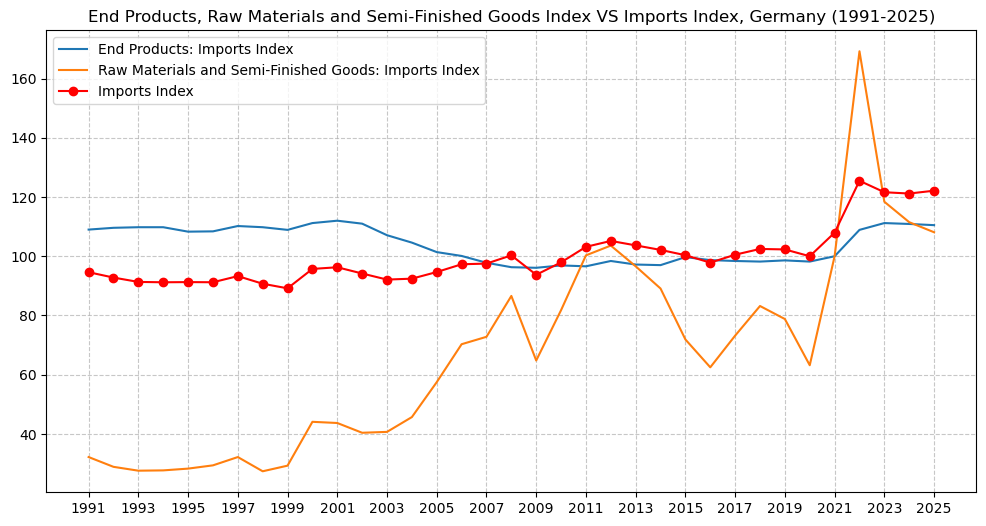

In [265]:
plt.figure(figsize=(12, 6))

# plt.plot(merged_imp['food of animal origin'].astype(float), label="Finished Goods: Exports Index")
plt.plot(merged_imp['end products'].astype(float), label="End Products: Imports Index")
plt.plot(merged_imp['raw materials and semi-finished goods'].astype(float), label="Raw Materials and Semi-Finished Goods: Imports Index")

# plt.plot(x.index, x.values.astype(float), color='blue', marker='o', linestyle='-', label="Terms of Trade")
plt.plot(x.index, i.values.astype(float), color='red', marker='o', linestyle='-', label="Imports Index")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1991, 2026, 2))
plt.title("End Products, Raw Materials and Semi-Finished Goods Index VS Imports Index, Germany (1991-2025)")
plt.show()

In [165]:
# 1. Merge the two DataFrames on 'year'
# We add suffixes so we know which column is which
df_final = pd.merge(merged_exp, merged_imp, on='year', suffixes=('_exp', '_imp')).astype(float)

# 2. Calculate Sectoral Terms of Trade
# Example for Finished Goods
df_final['tot_finished'] = (df_final['finished goods_exp'] / df_final['finished goods_imp']) * 100

# Example for Intermediate Products
df_final['tot_intermediate'] = (df_final['intermediate products_exp'] / df_final['intermediate products_imp']) * 100

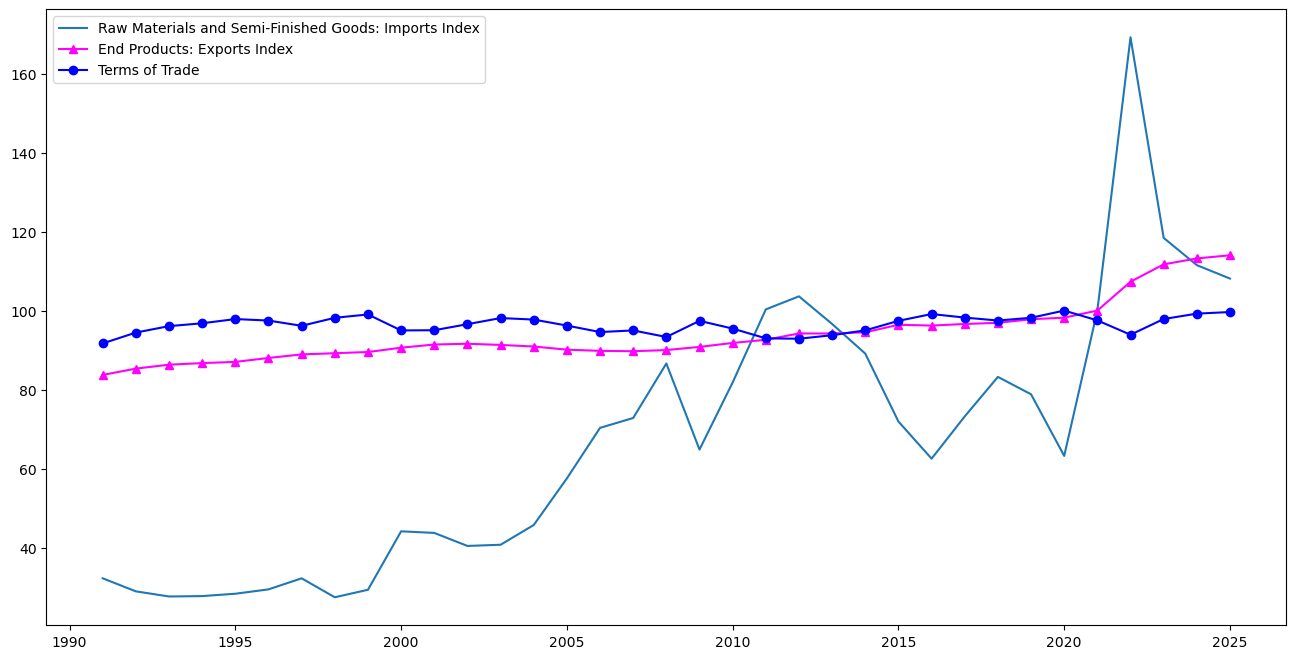

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(merged_imp['raw materials and semi-finished goods'].astype(float), label="Raw Materials and Semi-Finished Goods: Imports Index")
plt.plot(merged_exp['end products'].astype(float), color='magenta', marker="^", label="End Products: Exports Index")
plt.plot(x.index, x.values.astype(float), color='blue', marker='o', linestyle='-', label="Terms of Trade")
plt.title("")
plt.legend()


In [207]:
merged_imp['raw materials and semi-finished goods'].corr(df_tot['terms of trade'])

-0.13495108712230156

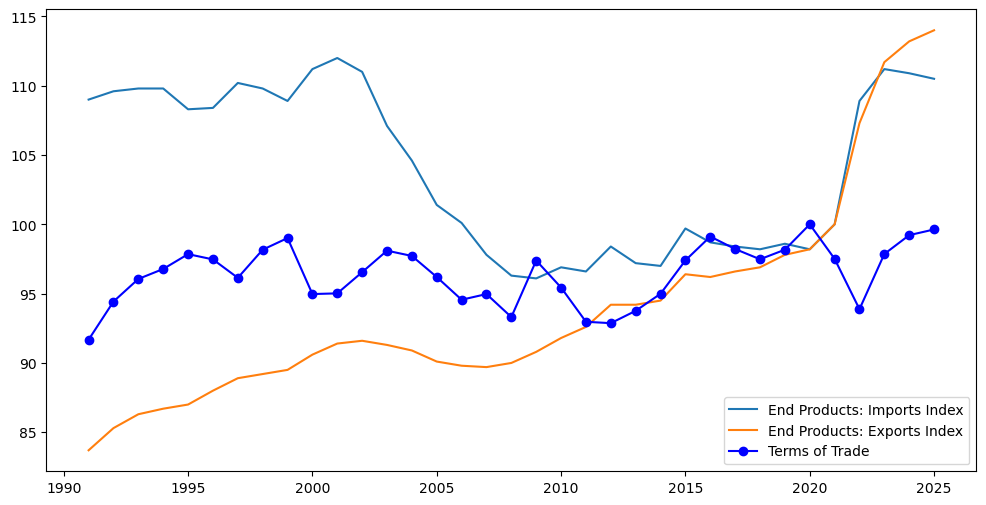

In [220]:
plt.figure(figsize=(12,6))
plt.plot(merged_imp['end products'].astype(float), label="End Products: Imports Index")
plt.plot(merged_exp['end products'].astype(float), label="End Products: Exports Index")
plt.plot(x.index, x.values.astype(float), color='blue', marker='o', linestyle='-', label="Terms of Trade")
plt.legend()
plt.show()

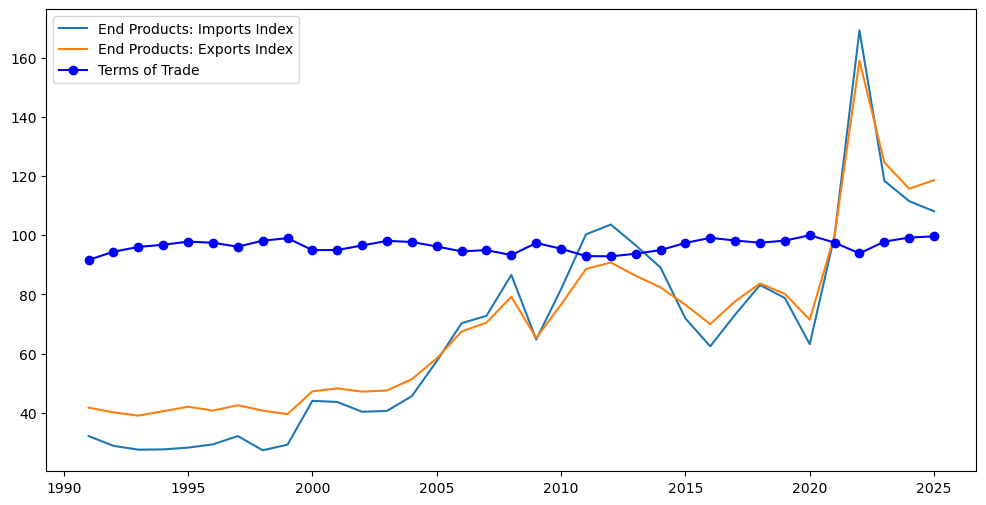

In [219]:
plt.figure(figsize=(12,6))
plt.plot(merged_imp['raw materials and semi-finished goods'].astype(float), label="End Products: Imports Index")
plt.plot(merged_exp['raw materials and semi-finished goods'].astype(float), label="End Products: Exports Index")
plt.plot(x.index, x.values.astype(float), color='blue', marker='o', linestyle='-', label="Terms of Trade")
plt.legend()
plt.show()

/var/folders/bs/j9ww8bm55_j9bc_3kbwlvddm0000gp/T/ipykernel_96343/3631909727.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


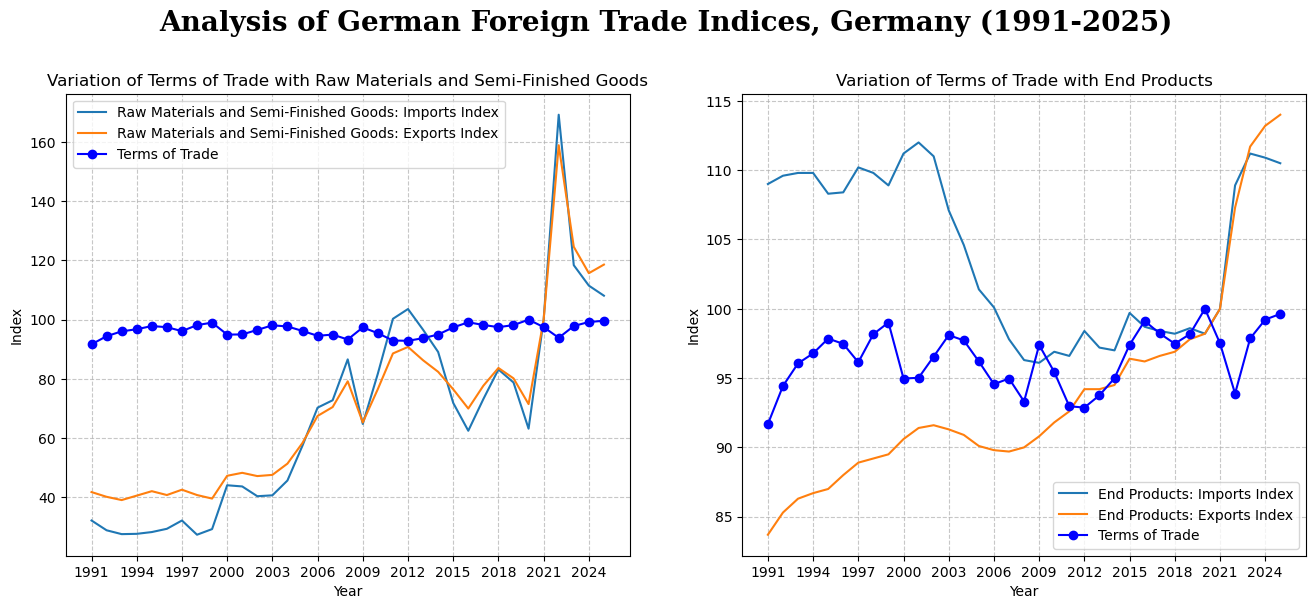

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# First Plot
ax1.plot(merged_imp['raw materials and semi-finished goods'].astype(float), label="Raw Materials and Semi-Finished Goods: Imports Index")
ax1.plot(merged_exp['raw materials and semi-finished goods'].astype(float), label="Raw Materials and Semi-Finished Goods: Exports Index")
ax1.plot(x.index, x.values.astype(float), color='blue', marker='o', linestyle='-', label="Terms of Trade")
ax1.set(xlabel="Year", ylabel="Index", title="Variation of Terms of Trade with Raw Materials and Semi-Finished Goods", xticks=range(1991, 2026, 3))
ax1.legend()

ax2.plot(merged_imp['end products'].astype(float), label="End Products: Imports Index")
ax2.plot(merged_exp['end products'].astype(float), label="End Products: Exports Index")
ax2.plot(x.index, x.values.astype(float), color='blue', marker='o', linestyle='-', label="Terms of Trade")
plt.xticks(range(1991, 2026, 2))
ax2.legend()
ax2.set(xlabel="Year", ylabel="Index", title="Variation of Terms of Trade with End Products",  xticks=range(1991,2026,3),)
fig.suptitle("Analysis of German Foreign Trade Indices, Germany (1991-2025)", fontsize=20, fontfamily='serif', fontweight='bold', y=1.02,)
ax2.grid(True, linestyle='--', alpha=0.7)
ax1.grid(True, linestyle='--', alpha=0.7)
fig.show()